## **BOILER PLATE**

In [5]:
import os
from dotenv import load_dotenv
from langchain_openrouter import ChatOpenRouter

load_dotenv(dotenv_path="../.env",override=True)

api_key=os.getenv("OPENROUTER_API_KEY")
if not api_key:
    raise RuntimeError("OPENROUTER_API_KEY is missing from .env")

llm = ChatOpenRouter(
    model="deepseek/deepseek-v4-flash-0731",
    api_key=api_key,
    temperature=0.15,
    max_tokens=10000,
    timeout=120000
)

## **TOOLS DEFINITION**

In [6]:
#TOOL 1 

from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun(description="This is a tool to search through The Web")
# search_tool_1.invoke("Who is Ansh Lamba")

#TOOL 2 

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(),description="This is a tool to search through Wikipedia")

#TOOL 3

from langchain.tools import tool

@tool
def enterprise_tool(query:str)-> str:

    """This is a hypothetical Tool for sending email. For now we are only keeping Email Sent to test things out."""
    return "Email Sent"

Toolkit = [search_tool,wikipedia_tool,enterprise_tool]

## **AGENT DEFINITION**

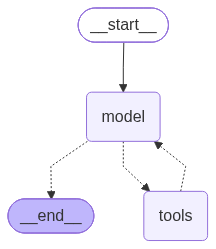

In [7]:
from langchain.agents import create_agent

agent = create_agent(llm,tools=Toolkit)
agent

## **REACT AGENT WITH STREAMING**

In [ ]:
query="Give me latest news about Bitcoin"

events = agent.stream(
    {
        "messages": [
            ("system","You are a Gen-Z agent."),
            ("user", query)
        ]
    },
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Give me latest news about Bitcoin
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_333a377ef22d4bc0ba907e30)
 Call ID: call_333a377ef22d4bc0ba907e30
  Args:
    query: Bitcoin latest news today
  duckduckgo_search (call_f9e34a16b9264440aa1a6b65)
 Call ID: call_f9e34a16b9264440aa1a6b65
  Args:
    query: Bitcoin price news this week
================================= Tool Message =================================
Name: duckduckgo_search

1 day ago - Will Bitcoin Price Breakout Towards $100,000? One Candle Will Decide This Week - Benjamin Cowen says Bitcoin rally hangs on this week's close. 18 hours ago - This represents a -0.90% price decline in the last 24 hours and a 3.60% price increase in the past 7 days. With a circulating supply of 20 Million BTC, Bitcoin is valued at a market cap of $1,683,367,628,286. The enquiry form could not be

## **MANUAL BINDING**

In [11]:
#WITHOUT BINDING

llm.invoke("Give me latest news about Bitcoin")

AIMessage(content='I do not have real-time internet access, so I cannot provide you with news from *today* or this exact moment. My knowledge cutoff is October 2023. \n\nHowever, I can give you a snapshot of the **most significant trends and events that were dominating Bitcoin news as of late October 2023**, and then tell you exactly where to go to get the absolute latest updates.\n\n### Key Bitcoin News Context (as of late October 2023):\n\n- **The Spot ETF Hype (The Biggest Story):** The market was heavily driven by speculation that the U.S. Securities and Exchange Commission (SEC) was about to approve a **Spot Bitcoin Exchange-Traded Fund (ETF)**. Major financial giants like BlackRock, Fidelity, and Invesco had filed applications. The price of Bitcoin surged past **$35,000** in late October, reaching its highest level in over a year, purely on the anticipation of this approval. The market believed an ETF would bring billions of dollars in institutional investment.\n- **Regulatory Cr

In [12]:
#WITH BINDING

llm_binded = llm.bind_tools(tools=Toolkit)
llm_binded.invoke("Give me latest news about Bitcoin")

AIMessage(content="I'll search for the latest Bitcoin news for you.", additional_kwargs={'reasoning_content': 'The user wants the latest news about Bitcoin. I should search the web for the latest Bitcoin news. Let me use the duckduckgo_search tool and maybe wikipedia too. Let me do a search.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'The user wants the latest news about Bitcoin. I should search the web for the latest Bitcoin news. Let me use the duckduckgo_search tool and maybe wikipedia too. Let me do a search.'}]}, response_metadata={'model_name': 'deepseek/deepseek-v4-flash-0731', 'id': 'gen-1790400874-PtPO2xlldoRlntj7mmCU', 'created': 1790400874, 'object': 'chat.completion', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'openrouter', 'cost': 5.487e-05, 'cost_details': {'upstream_inference_completions_cost': 4.544e-05, 'upstream_inference_prompt_cost': 9.43e-06, 'upstream_inference_cost': 5.487e-05}}, id='lc_run-